In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('D:\\sales-intelligence-system\\data\\raw\\SampleSuperstore.csv')

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.describe()# Check for missing values

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [9]:
df.shape

(9994, 13)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

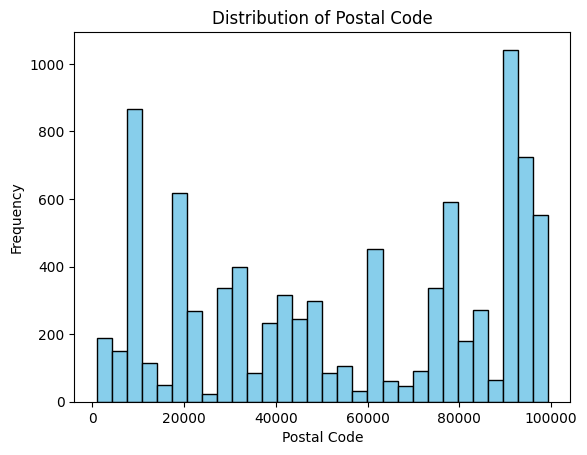

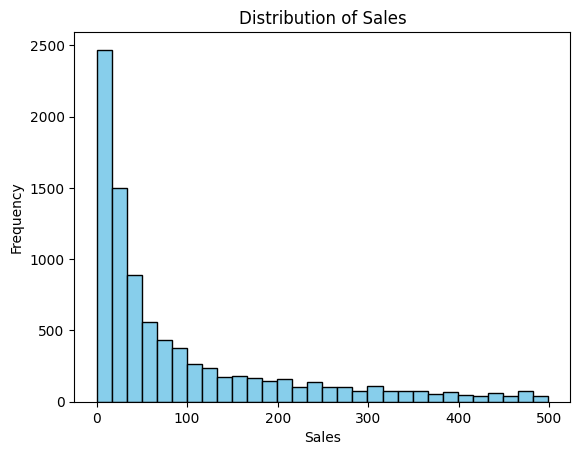

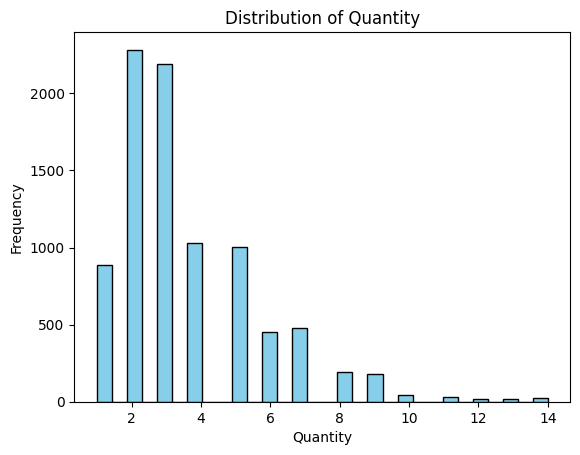

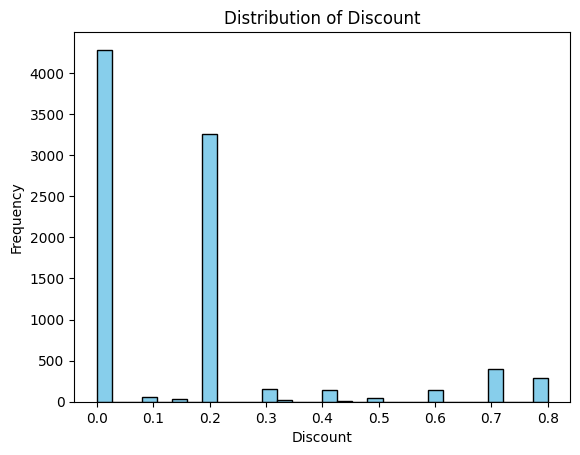

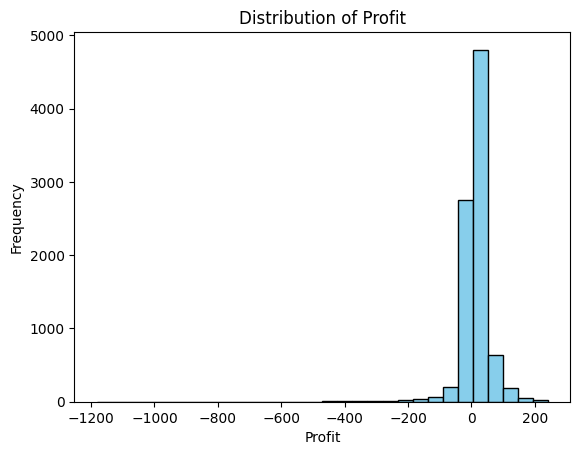

In [30]:
# histogram for all numeric columns
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
for col in numeric_cols:
    plt.hist(df_cleaned[col], bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='Category', ylabel='Sales'>

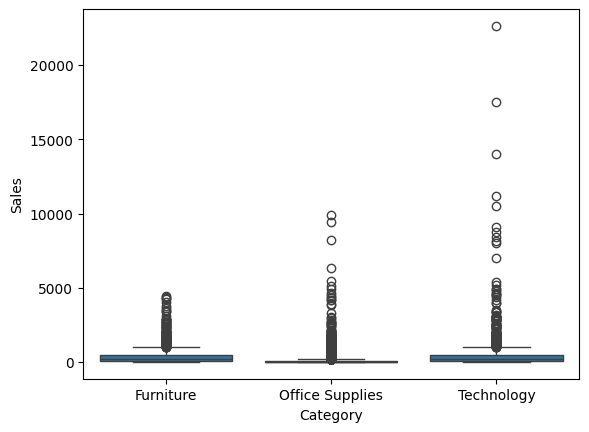

In [ ]:
#Boxplot of Sales by Category
sns.boxplot(x='Category', y='Sales', data=df)

In [21]:
# Identify outliers using IQR
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [22]:

df_cleaned = df[~((df['Sales'] < lower_bound) | (df['Sales'] > upper_bound))]


In [23]:
df_cleaned.shape

(8827, 13)

<Axes: xlabel='Category', ylabel='Sales'>

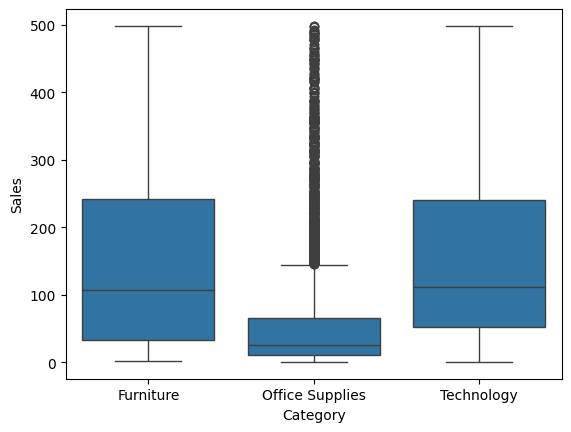

In [24]:
sns.boxplot(x='Category', y='Sales', data=df_cleaned)

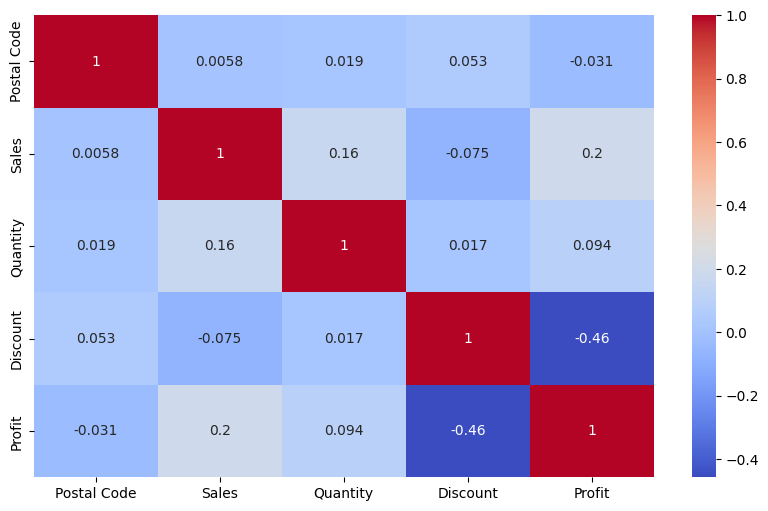

In [25]:
#correlation matrix
correlation_matrix = df_cleaned.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()  

In [26]:
print(correlation_matrix)
#the correlation matrix shows that there is a strong positive correlation between Sales and Profit, 
# which means that as sales increase, profit also tends to increase.
# There is also a moderate positive correlation between Sales and Quantity, indicating that higher sales are often associated with higher quantities sold.
# The correlation between Sales and Discount is weakly negative, suggesting that higher discounts may slightly reduce sales.

             Postal Code     Sales  Quantity  Discount    Profit
Postal Code     1.000000  0.005842  0.018717  0.052600 -0.031287
Sales           0.005842  1.000000  0.161537 -0.075480  0.196448
Quantity        0.018717  0.161537  1.000000  0.017105  0.094351
Discount        0.052600 -0.075480  0.017105  1.000000 -0.457813
Profit         -0.031287  0.196448  0.094351 -0.457813  1.000000


In [27]:
#dumping the cleaned data to a new csv file
df_cleaned.to_csv('D:\\sales-intelligence-system\\data\\processed\\SampleSuperstore_cleaned.csv', index=False)

In [32]:
def validate_data(df):
    assert df.isnull().sum().sum() == 0, "Missing values still exist!"
    assert (df['quantity'] >= 0).all(), "Negative quantity found!"
    assert (df['price'] >= 0).all(), "Negative price found!"
    return True

print(validate_data(df_cleaned))

KeyError: 'quantity'

In [33]:
df_cleaned.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.960,2,0.0,41.9136
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.620,2,0.0,6.8714
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.368,2,0.2,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.860,7,0.0,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.280,4,0.0,1.9656


In [ ]:


def clean_data(df):
    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Handle missing values
    df.fillna({
        'Sales': df['Sales'].mean(),
        'Quantity': 1,
        'Discount': 0,
        'Profit': 0
    }, inplace=True)

    # 🔹 Create price (approximate)
    df['price'] = df['Sales'] / df['Quantity']

    # 🔹 Total amount
    df['total_amount'] = df['Sales']

    # 🔹 Rename columns
    df.rename(columns={
        'Region': 'region'
    }, inplace=True)

    # 🔹 Create product_id
    df['product_id'] = (
        df['Category'] + "_" + df['Sub-Category']
    ).astype('category').cat.codes

    # 🔹 Create customer_id
    df['customer_id'] = (
        df['City'] + "_" + df['Segment']
    ).astype('category').cat.codes

    # 🔹 Create fake date (IMPORTANT FIX)
    df['date'] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')

    # 🔹 Select required columns
    df = df[['date', 'product_id', 'customer_id', 'Quantity', 'price', 'total_amount', 'region']]

    # Rename Quantity → quantity
    df.rename(columns={'Quantity': 'quantity'}, inplace=True)

    return df